Chart 1: A multi-line trend chart tracking quarterly revenue across all 4 primary divisions.

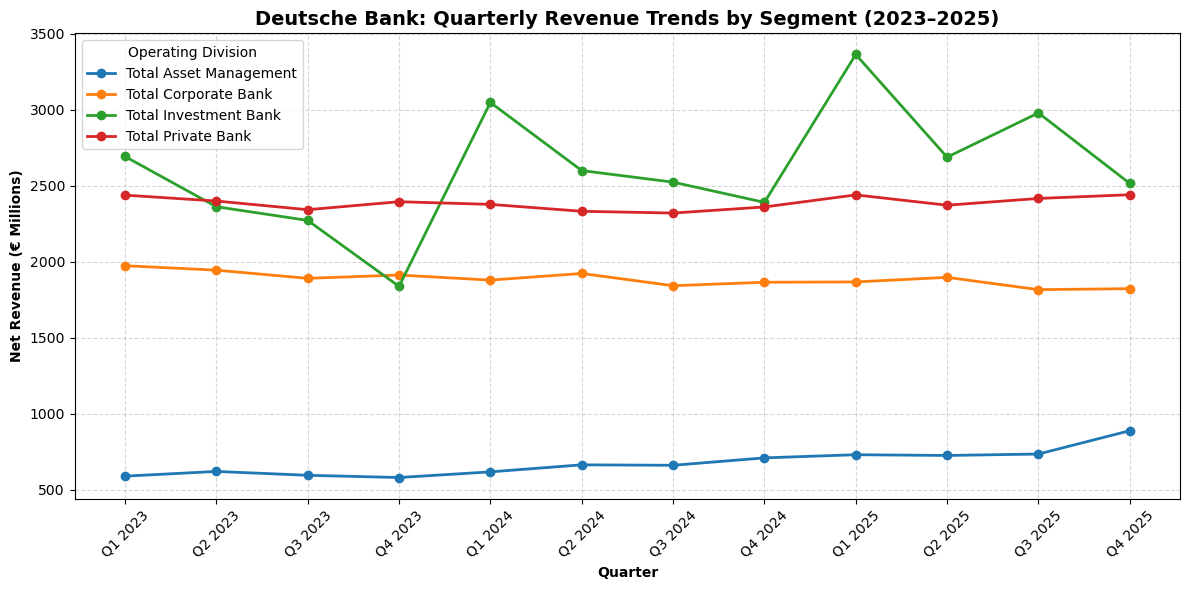

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# 1. Fetch data from SQLite
conn = sqlite3.connect('deutsche_bank.db')

sql_trend = """
SELECT 
    period,
    segment,
    revenue_eur_m
FROM net_revenues
WHERE segment IN (
    'Total Corporate Bank',
    'Total Investment Bank',
    'Total Private Bank',
    'Total Asset Management'
);
"""

df_trend = pd.read_sql(sql_trend, conn)
conn.close()

# 2. Reshape data using pivot for plotting
df_pivot = df_trend.pivot(index='period', columns='segment', values='revenue_eur_m')

# Reorder quarters chronologically
ordered_periods = [
    'Q1 2023', 'Q2 2023', 'Q3 2023', 'Q4 2023',
    'Q1 2024', 'Q2 2024', 'Q3 2024', 'Q4 2024',
    'Q1 2025', 'Q2 2025', 'Q3 2025', 'Q4 2025'
]
df_pivot = df_pivot.reindex(ordered_periods)

# 3. Create Plot
plt.figure(figsize=(12, 6))

for column in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[column], marker='o', linewidth=2, label=column)

plt.title('Deutsche Bank: Quarterly Revenue Trends by Segment (2023–2025)', fontsize=14, fontweight='bold')
plt.xlabel('Quarter', fontweight='bold')
plt.ylabel('Net Revenue (€ Millions)', fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Operating Division')
plt.tight_layout()

# Save chart as image file for portfolio
plt.savefig('quarterly_revenue_trends.png', dpi=300)
plt.show()

Chart 2: A YoY Growth (%) bar chart for the Investment Banking division.

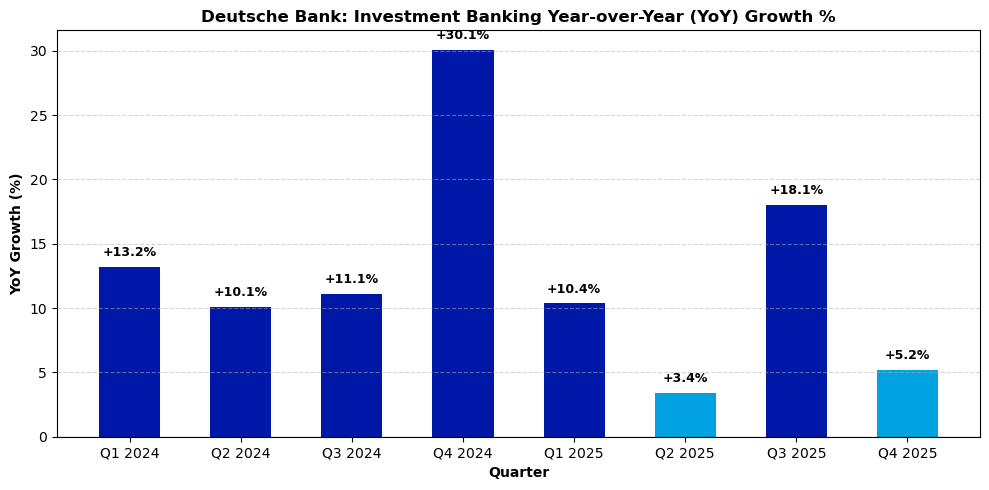

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# 1. Fetch variance data from SQLite
conn = sqlite3.connect('deutsche_bank.db')

sql_yoy = """
WITH ordered_quarters AS (
    SELECT 
        period,
        revenue_eur_m,
        SUBSTR(period, 4, 4) AS yr,
        SUBSTR(period, 1, 2) AS qtr
    FROM net_revenues
    WHERE segment = 'Total Investment Bank'
    ORDER BY yr ASC, qtr ASC
)
SELECT 
    period,
    ROUND(((revenue_eur_m - LAG(revenue_eur_m, 4) OVER ()) / LAG(revenue_eur_m, 4) OVER ()) * 100, 2) AS yoy_growth_pct
FROM ordered_quarters;
"""

df_yoy = pd.read_sql(sql_yoy, conn)
conn.close()

# Drop rows where YoY is NaN (first 4 quarters of 2023)
df_yoy_clean = df_yoy.dropna().reset_index(drop=True)

# 2. Plot Bar Chart
plt.figure(figsize=(10, 5))

# Color coding: dark blue for >= 10% growth, light blue for < 10%
colors = ['#0018A8' if g >= 10 else '#00A3E0' for g in df_yoy_clean['yoy_growth_pct']]
bars = plt.bar(df_yoy_clean['period'], df_yoy_clean['yoy_growth_pct'], color=colors, width=0.55)

plt.axhline(0, color='black', linewidth=0.8)
plt.title('Deutsche Bank: Investment Banking Year-over-Year (YoY) Growth %', fontsize=12, fontweight='bold')
plt.xlabel('Quarter', fontweight='bold')
plt.ylabel('YoY Growth (%)', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add numeric value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.6, f'+{yval:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('yoy_growth_bar_chart.png', dpi=300)
plt.show()

STEP5: EXPORTING THE NOTEBOOK AS CSV FILE

In [6]:
import pandas as pd

file_path = "C:/Users/user/Desktop/Deutsche_Bank_NetRevenue_Report.xlsx"

def clean_excel_sheet(file_path, sheet_name, quarters):
    df = pd.read_excel(file_path, sheet_name=sheet_name, skiprows=2)
    df.columns = [str(c).strip() for c in df.iloc[0]]
    df = df.iloc[1:].reset_index(drop=True)
    df.rename(columns={df.columns[0]: 'segment'}, inplace=True)
    cols_to_keep = ['segment'] + quarters
    df_filtered = df[cols_to_keep].dropna(subset=['segment']).copy()
    
    df_long = df_filtered.melt(
        id_vars=['segment'],
        value_vars=quarters,
        var_name='period',
        value_name='revenue_eur_m'
    )
    df_long['revenue_eur_m'] = pd.to_numeric(df_long['revenue_eur_m'], errors='coerce')
    return df_long

# Define Quarters
q_22_24 = ['Q1 2023', 'Q2 2023', 'Q3 2023', 'Q4 2023', 'Q1 2024', 'Q2 2024', 'Q3 2024', 'Q4 2024']
q_24_25 = ['Q1 2025', 'Q2 2025', 'Q3 2025', 'Q4 2025']

# Process and Combine
df_part1 = clean_excel_sheet(file_path, 'NetRevenues(22-24)', q_22_24)
df_part2 = clean_excel_sheet(file_path, 'NetRevenues(24-25)', q_24_25)
full_dataset = pd.concat([df_part1, df_part2], ignore_index=True)

# Export to CSV for Tableau
full_dataset.to_csv('Deutsche_Bank_NetRevenues_Clean.csv', index=False)
print("CSV exported successfully for Tableau! Total rows:", len(full_dataset))

CSV exported successfully for Tableau! Total rows: 360
